## **OOP Revision**

In [11]:
class Person:
  def __init__(self, name, age):
    self.name = name
    self.age = age
p1 = Person("linus",23)

# print(p1.name)
# print(p1.age)
print(f"The person name is {p1.name} & age is {p1.age}")

linus
23
The person name is linus & age is 23


In [18]:
class Parent:
    def __init__(self):
        print("Parent is setting up")

class Child(Parent):        # Child inherits Parent
    def __init__(self):
        # super().__init__()  # run Parent's setup first
        print("Parent is setting up")
        print("Child is setting up")

c = Child()

Parent is setting up
Child is setting up


In [23]:
class parent:
  def __init__(self):
    self.secret = 42
    self.config = {'lr': 0.01}

  def __str__(self):
    return f"parent(secret={self.secret}, config={self.config})"

c = parent()
print(c)

parent(secret=42, config={'lr': 0.01})


In [26]:
class Parent:
    def __init__(self, name):
        self.name = name
        self.secret = 42
        print(f"Parent set name: {self.name}")

class Child(Parent):
    def __init__(self, name, age):
        super().__init__(name)    # passes name UP to Parent
        self.age = age
        print(f"Child set age: {self.age}")

c = Child("Fahad", 23)

# now try accessing both:
print(c.name)    # set by Parent
print(c.age)     # set by Child
print(c.secret)  # also set by Parent

Parent set name: Fahad
Child set age: 23
Fahad
23
42


## **PyTorch Parent Class**

In [28]:
import torch.nn as nn
print(dir(nn.Module))

['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_call_impl', '_compiled_call_impl', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_load_from_state_dict', '_maybe_warn_non_full_backward_hook', '_named_members', '_register_load_state_dict_pre_hook', '_register_state_dict_hook', '_replicate_for_data_parallel', '_save_to_state_dict', '_slow_forward', '_version', '_wrapped_call_impl', 'add_module', 'apply', 'bfloat16', 'buffers', 'call_super_init', 'children', 'compile', 'cpu', 'cuda', 'double', 'dump_patches', 'eval', 'extra_repr', 'float', 'forward', 'get_buffer', 'get_extra_

In [98]:
# Lets print it clean
props = [p for p in dir(nn.Module) if not p.startswith('_')]
for p in props:
    print(p)

T_destination
add_module
apply
bfloat16
buffers
call_super_init
children
compile
cpu
cuda
double
dump_patches
eval
extra_repr
float
forward
get_buffer
get_extra_state
get_parameter
get_submodule
half
ipu
load_state_dict
modules
mtia
named_buffers
named_children
named_modules
named_parameters
parameters
register_backward_hook
register_buffer
register_forward_hook
register_forward_pre_hook
register_full_backward_hook
register_full_backward_pre_hook
register_load_state_dict_post_hook
register_load_state_dict_pre_hook
register_module
register_parameter
register_state_dict_post_hook
register_state_dict_pre_hook
requires_grad_
set_extra_state
set_submodule
share_memory
state_dict
to
to_empty
train
type
xpu
zero_grad


## **Now building a real minimal model end to end — define it, pass data through it, see output**

## **Real Math behind the scenes**

In [69]:
# 1. Install & import
import torch
import torch.nn as nn

In [70]:
# 2. Build the model
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(3,1) # 3 inputs → 1 output

  ## Lets do the math behind nn.linear()

    # Formula: output = (input × weight) + bias
    # Formula: x × w + bias

    # 3 inputs
    # x  = [2.0, 5.0, 3.0]   # size, rooms, age

    # 3 weights randomly assigned (Will be learned durin training)
    # w  = [0.5, 1.2, 0.3]

    # bias: 1.0

  ## Lets put the values:

    # output = (x*w) + (x*w) + (x*w) +bias
    # output = (2.0 * 0.5) + (5.0 * 1.2) + (3.0 + 0.3) + 1.0

  ## How will it look like in pure Python? No PyTorch

    # x = [2.0, 5.0, 3.0]
    # w = [0.5, 1.2, 0.3]
    # bias = 1.0

    # output = sum(xi*wi for xi, wi in zip(x,w))
    # print(output)  # 8.9

  ## How PyTorch doing it Manual
  # manually set same weights and bias

    # layer.weight = nn.Parameter(torch.tensor([[0.5, 1.2, 0.3]]))
    # layer.bias   = nn.Parameter(torch.tensor([1.0]))

    # x      = torch.tensor([[2.0, 5.0, 3.0]])
    # output = layer(x)
    # print(output)  # same 8.9

  def forward(self,x):
    return self.layer(x)

model = MyModel()
x = torch.randn(1,3)
output = model(x)
print(output)

tensor([[-0.7034]], grad_fn=<AddmmBackward0>)


In [71]:
# 3. Loss Calculation
y = torch.tensor([[2.0]]) # Suppose this is real answer I need to predict
criterion = nn.MSELoss() # MSE = Mean Squared Error

# Math Behind:
# Formula:loss = (predicted - actual)²
        # loss = (0.9591 - 2.0)²
        # loss = (-1.0409)²
        # loss = 1.083

loss = criterion(output, y)
print("Predicted:", output.item())
print("Actual:   ", 2.0)
print("Loss:     ", loss.item())

Predicted: -0.7034448385238647
Actual:    2.0
Loss:      7.308614730834961


In [72]:
# All Above have this chain:

# x → (x×w + b) → output → (output - y)² → loss

In [73]:
# 4. Backward Pass
loss.backward()

print("Weight Gradients: ", model.layer.weight.grad)
print("Bias Gradients: ", model.layer.bias.grad)

Weight Gradients:  tensor([[-8.4870, 10.1750, -6.1455]])
Bias Gradients:  tensor([-5.4069])


In [74]:
# Formulas to remember for gradients

# # Derivative
# dy/dx = lim(h→0) [f(x+h) - f(x)] / h

# # Power Rule
# d/dx [xⁿ] = nxⁿ⁻¹

# # Chain Rule
# dy/dx = dy/du × du/dx

# # In PyTorch terms
# d(loss)/d(w) = d(loss)/d(output) × d(output)/d(w)

In [75]:
# loss.backward() goes backwards through this chain and asks:

# "If I increase this weight by a tiny amount, does loss go up or down?"

# That answer = gradient

## Concrete example:

# w = 0.5   →   loss = 1.08
# w = 0.51  →   loss = 1.09   ← went up, so gradient is positive
# w = 0.49  →   loss = 1.07   ← went down, so nudge this way

# Gradient tells : which direction to move the weight.

# weight gradient = 0.8    → this weight caused too much error, reduce it
# weight gradient = -0.3   → this weight needs to increase
# weight gradient = 0.0    → this weight is fine

In [76]:
# # Behind the scene math of gradient

# It uses calculus chain rule

# One goal:

# "How much did each weight contribute to the error?"

In [77]:
# The chain:
# w → output → loss

# To find "how much did w affect loss" — you go backwards:

# how much did w affect output?   ×   how much did output affect loss?

# That's chain rule. Just multiply two slopes together.

In [78]:
# Concrete numbers:

# output = x×w + b
# loss   = (output - y)²

# Step 1 — slope of loss over output:

# d(loss)/d(output) = 2 × (output - y)
#                   = 2 × (0.9591 - 2.0)
#                   = -2.08


# Step 2 — slope of output over w:
# d(output)/d(w) = x = [-0.5, 1.2, 0.8]


# Step 3 — multiply (chain rule):
# gradient = -2.08 × [-0.5, 1.2, 0.8]
#          = [1.04, -2.49, -1.66]


# Those are your weight gradients.

# Plain english:
# positive gradient → weight is too high → bring it down
# negative gradient → weight is too low  → bring it up

In [79]:
# 5. Optimizer (Adam)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# weights BEFORE
print("Before:", model.layer.weight.data)

optimizer.step()   # adjust weights using gradients

# weights AFTER
print("After: ", model.layer.weight.data)

Before: tensor([[-0.4229, -0.2171, -0.3555]])
After:  tensor([[-0.4129, -0.2271, -0.3455]])


In [80]:
# # Maths Behind

# # Basic Gradient Descent (SGD)
# new_weight = old_weight - (lr × gradient)

# # Adam
# m = beta1 × m + (1 - beta1) × gradient          # smooth the direction
# v = beta2 × v + (1 - beta2) × gradient²         # smooth the size
# new_weight = old_weight - (lr × m / (√v + ε))   # smart step

In [81]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()          # clear old gradients
    output = model(x)              # forward
    loss = criterion(output, y)    # loss
    loss.backward()                # gradients
    optimizer.step()               # fix weights

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 0 Loss: 7.0096
Epoch 10 Loss: 4.3818
Epoch 20 Loss: 2.4524
Epoch 30 Loss: 1.1953
Epoch 40 Loss: 0.4881
Epoch 50 Loss: 0.1568
Epoch 60 Loss: 0.0348
Epoch 70 Loss: 0.0035
Epoch 80 Loss: 0.0000
Epoch 90 Loss: 0.0007


In [82]:
with torch.no_grad():
    prediction = model(x)
    print("Final prediction:", prediction.item())
    print("Actual:          ", 2.0)

Final prediction: 2.0266454219818115
Actual:           2.0


#**Optimizers in Detail**

In [86]:
# SGD       ← simplest, basic gradient descent
# Momentum  ← SGD but with memory of past direction
# RMSprop   ← adapts lr per weight
# Adam      ← RMSprop + Momentum combined ← most popular
# AdamW     ← Adam + weight decay fix ← used in transformers/LLMs
# Adagrad   ← older, rarely used now

### **1. SGD — Stochastic Gradient Descent**

In [85]:
# The idea:

# You have a weight. It's wrong. You want to fix it.
# error tells you → which direction to move

# lr tells you    → how big the step

In [84]:
# The formula:

# new_weight = old_weight - lr × gradient

In [88]:
# Example
# # imagine one weight
# w         = 0.5
# lr        = 0.1
# gradient  = 2.0    # backprop calculated this

# # SGD step:
# w = w - lr × gradient
# w = 0.5 - (0.1 × 2.0)
# w = 0.5 - 0.2
# w = 0.3              # weight moved

#### **1. Vanilla SGD**

In [ ]:
# Vanilla SGD    → blind steps, same size every time, slow

In [89]:
# 1. Vanilla SGD

w        = 0.5
lr       = 0.1
gradient = 2.0

for i in range(5):
    w = w - lr * gradient
    print(f"Step {i+1}: w = {w:.4f}")

Step 1: w = 0.3000
Step 2: w = 0.1000
Step 3: w = -0.1000
Step 4: w = -0.3000
Step 5: w = -0.5000


Weight is moving the same size step every single time — -0.2 each step, forever.


In [ ]:
# far from target  → gradient is big   → big step ✅ good
# close to target  → gradient is small → small step ✅ good

# But vanilla SGD doesn't know if you're close or far — it just blindly follows the gradient. Two problems:

# 1. Too slow in flat regions     → gradient ≈ 0 → barely moves
# 2. Oscillates in steep regions  → bounces back and forth, never settles

In [90]:
w        = 0.5
lr       = 0.5    # bigger lr
gradient = 2.0

for i in range(6):
    w = w - lr * gradient
    print(f"Step {i+1}: w = {w:.4f}")

Step 1: w = -0.5000
Step 2: w = -1.5000
Step 3: w = -2.5000
Step 4: w = -3.5000
Step 5: w = -4.5000
Step 6: w = -5.5000


see it overshoot and bounce.

#### **2. SGD + Momentum**

In [ ]:
# Momentum       → builds speed, overshoots but gets there faster

In [91]:
# 2. SGD + Momentum

# SGD + Momentum fixes this:

# Instead of just using current gradient — remember past direction too:

# velocity = momentum × velocity + gradient
# w        = w - lr × velocity

# velocity builds up in the right direction and slows down when gradient changes direction.
# Like a ball rolling downhill — builds speed going down, naturally slows at the bottom.

In [94]:
w        = 10.0
target   = 0.0
lr       = 0.1
momentum = 0.9
velocity = 0.0

for i in range(50):
    gradient = w - target
    velocity = momentum * velocity + gradient
    w        = w - lr * velocity
    if i % 5 == 0:
        print(f"Step {i+1:2d}: w = {w:8.4f}")

Step  1: w =   9.0000
Step  6: w =  -2.5661
Step 11: w =  -5.1648
Step 16: w =   1.8165
Step 21: w =   2.9438
Step 26: w =  -1.2443
Step 31: w =  -1.6657
Step 36: w =   0.8319
Step 41: w =   0.9351
Step 46: w =  -0.5458


watch how velocity builds up and how w behaves differently.

In [95]:
w_sgd = 10.0
w_mom = 10.0
velocity = 0.0
lr       = 0.1
momentum = 0.9

print(f"{'Step':<6} {'Vanilla SGD':<15} {'Momentum':<15}")
print("-" * 36)

for i in range(10):
    # vanilla SGD
    grad_sgd = w_sgd
    w_sgd    = w_sgd - lr * grad_sgd

    # momentum
    grad_mom = w_mom
    velocity = momentum * velocity + grad_mom
    w_mom    = w_mom - lr * velocity

    print(f"{i+1:<6} {w_sgd:<15.4f} {w_mom:<15.4f}")

Step   Vanilla SGD     Momentum       
------------------------------------
1      9.0000          9.0000         
2      8.1000          7.2000         
3      7.2900          4.8600         
4      6.5610          2.2680         
5      5.9049          -0.2916        
6      5.3144          -2.5661        
7      4.7830          -4.3565        
8      4.3047          -5.5322        
9      3.8742          -6.0372        
10     3.4868          -5.8879        


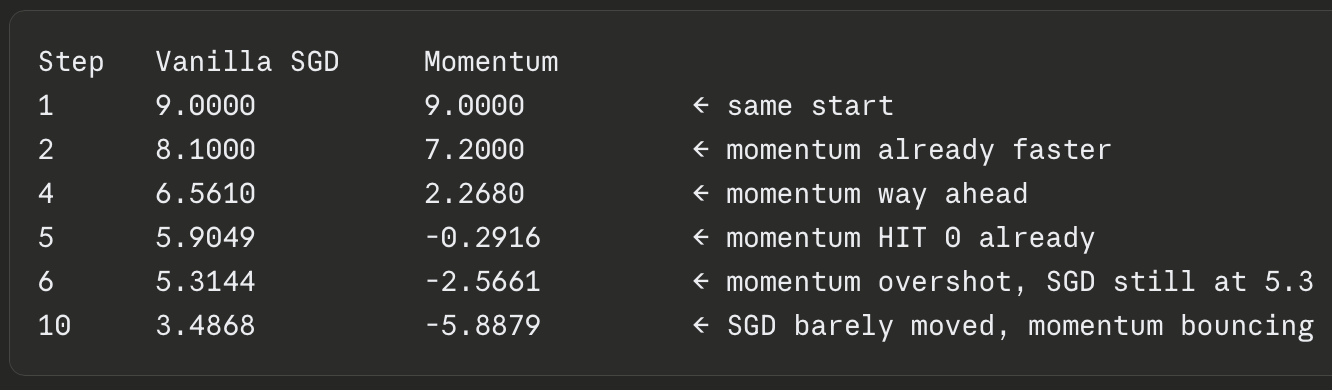

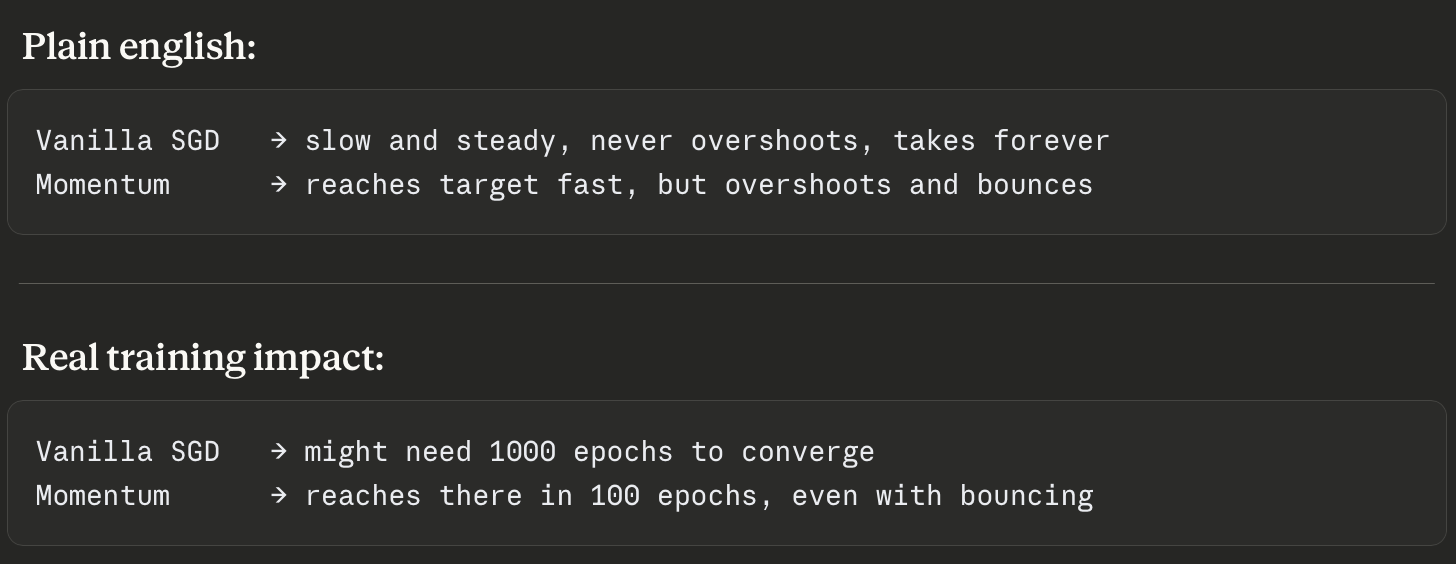

#### **SGD + Nesterov**

In [ ]:
# Nesterov       → momentum but looks ahead, less overshoot

In [ ]:
# SGD + Nesterov       → fast + looks ahead → less overshoot
# Instead of calculating gradient where you are — calculate it where you're about to be.

In [ ]:
# Nesterov — just add nesterov=True

# Regular Momentum
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# Nesterov — just add nesterov=True
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)

In [ ]:
# SGD + Momentum          → general training
# SGD + Nesterov          → when momentum overshoots too much

### **2. Adam — Adaptive Moment Estimation**

In [ ]:
# Adam           → momentum + smart step size per weight, best default

### **3. AdamW — Adam + Weight Decay fix**

In [ ]:
# AdamW          → Adam + correct weight decay, use for transformers

In [96]:
# # SGD
# torch.optim.SGD(model.parameters(), lr=0.01)

# # SGD + Momentum
# torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# # Adam
# torch.optim.Adam(model.parameters(), lr=0.001)

# # AdamW
# torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [ ]:
# Building transformer/LLM related?  → AdamW
# Everything else?                   → Adam
# Learning/experimenting?            → Adam

In [ ]:
# Small dataset, simple model      → SGD + Momentum
# CV models (ResNet, CNN)          → SGD + Momentum + Nesterov
# Everything else                  → Adam
# Transformers, LLMs, BERT, GPT    → AdamW always
# Fine tuning pretrained models    → AdamW
# Your MAC model                   → AdamW
# AeonAnima                        → AdamW

In [ ]:
# The signal to switch:

# loss not converging       → lower lr
# loss bouncing wildly      → lower lr or switch SGD→Adam
# overfitting               → AdamW (weight decay helps)
# training transformer      → AdamW, never vanilla Adam

## **The WHole Training Loop**

In [100]:
# data → forward pass → loss → gradients → optimizer → weights change → loss changes

In [101]:
# Forward pass  →  calculate output
# Loss          →  how wrong is output?
# Gradient      →  how wrong is each weight?
# Optimizer     →  fix the weights a little bit
# Repeat...     →  gets better every time!

# Nothing random after initialization.

In [102]:
# The only random part:

# 1. Initial weights     → random at start
# 2. torch.randn()       → random fake data for testing
# 3. batch order         → randomly shuffled

# Everything after that is pure math and cause effect.

In [103]:
# Every number you see has a reason:

# loss went down    → weights got closer to correct values
# loss went up      → lr too high, bad batch, or bug
# loss stuck        → lr too low, wrong architecture, dead neurons
# loss = 0.0        → perfect fit or data leakage
# loss fluctuating  → batch size too small or lr too high

In [104]:
# The model is just a math function. Math doesn't lie. Every output is caused by an input.